# ETFs: Label Engineering

This notebook implements label engineering for the ETFs case study.
Labels encode the economic hypothesis: can risk-adjusted momentum predict
forward returns across a multi-asset ETF universe?

## Learning Objectives

- Compute regression labels at 21-day (primary) and 5-day (variant) horizons
- Diagnose label autocorrelation induced by overlapping forward windows
- Evaluate label quality: IC of a raw momentum baseline with HAC-adjusted
  significance, measured on train+validation data only
- Generate walk-forward CV configuration from `setup.yaml`

## Book Reference

Chapter 7, Section 7.2 (Label Engineering)

## Prerequisites

- ETF data available via `load_etfs()`
- `config/setup.yaml` (defines the primary/variant labels, CV splits, and the
  sealed holdout window used to scope the baseline IC)

In [1]:
"""ETFs: Label Engineering."""

import warnings
from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns
import yaml
from ml4t.diagnostic.metrics import compute_ic_hac_stats

from data import load_etfs
from utils.modeling import get_cv_config
from utils.paths import get_case_study_dir
from utils.style import COLORS

warnings.filterwarnings("ignore")

CASE_DIR = get_case_study_dir("etfs")
LABELS_DIR = CASE_DIR / "labels"

In [2]:
# Production defaults — Papermill injects overrides for CI

## 1. Load Data

Load adjusted ETF prices. The forward-return labels are computed per symbol,
so no cross-sectional eligibility filter is applied here — point-in-time
eligibility (`eligibility.csv` from `01_feasibility_analysis`) is enforced
downstream in `03_financial_features`, where the trainable panel is assembled.

In [3]:
prices = (
    load_etfs()
    .select(["symbol", "timestamp", "open", "high", "low", "close", "volume"])
    .sort(["symbol", "timestamp"])
)

# Holdout boundary: the baseline IC below is measured on train+validation data
# only, so the sealed holdout is never used to set feature-engineering
# expectations.
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())
holdout_start = setup["evaluation"]["holdout_start"]

n_assets = prices["symbol"].n_unique()
date_range = f"{prices['timestamp'].min()} to {prices['timestamp'].max()}"
print(f"ETF Universe: {n_assets} assets, {len(prices):,} rows")
print(f"Date range: {date_range}")
print(f"Holdout start (sealed): {holdout_start}")

ETF Universe: 100 assets, 470,662 rows
Date range: 2006-01-03 to 2025-12-31
Holdout start (sealed): 2024-01-01


**Note**: The `close` column from `load_etfs()` is adjusted for splits and
dividends (verified in [`01_feasibility_analysis`](01_feasibility_analysis.ipynb) via SPY 2006 price level check).

## 2. Label Functions

**Regression** (`fwd_ret_Nd`): simple close-to-close forward return over $N$
trading days. Sampled daily, consecutive labels overlap by $N-1$ days, which
induces the serial correlation quantified in Section 4.1 and handled with HAC
adjustment in the baseline IC (Section 5). The primary label is the 21-day
horizon (monthly rebalancing); the 5-day variant tests a weekly horizon.

In [4]:
def create_regression_labels(df: pl.DataFrame, horizon: int = 21) -> pl.DataFrame:
    """Create forward return labels for regression.

    Uses close-to-close returns shifted forward by `horizon` trading days.
    """
    return df.with_columns(
        (pl.col("close").shift(-horizon).over("symbol") / pl.col("close") - 1).alias(
            f"fwd_ret_{horizon}d"
        )
    )

## 3. Apply Labels

We compute two label types:
- `fwd_ret_21d`: Primary regression label (matches monthly rebalancing)
- `fwd_ret_5d`: Variant regression label (tests weekly horizon)

In [5]:
labels_df = prices.sort(["symbol", "timestamp"])

# Regression labels at two horizons
labels_df = create_regression_labels(labels_df, horizon=21)
labels_df = create_regression_labels(labels_df, horizon=5)
print("Created regression labels: fwd_ret_21d, fwd_ret_5d")

Created regression labels: fwd_ret_21d, fwd_ret_5d


## 4. Label Distribution Summary

fwd_ret_21d: 468,562 samples | fwd_ret_5d: 470,162 samples


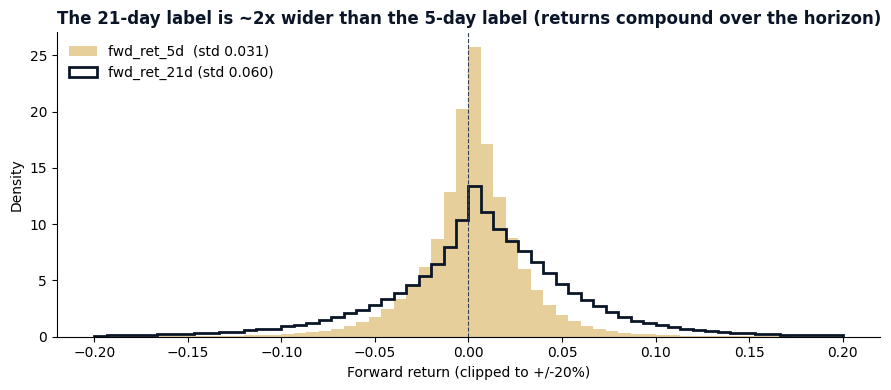

In [6]:
ret21 = labels_df["fwd_ret_21d"].drop_nulls().to_numpy()
ret5 = labels_df["fwd_ret_5d"].drop_nulls().to_numpy()
print(f"fwd_ret_21d: {len(ret21):,} samples | fwd_ret_5d: {len(ret5):,} samples")

# Overlaid densities on a shared axis make the horizon scaling visible: the
# 21-day label is ~sqrt(21/5) ~ 2x wider than the 5-day label, the signature of
# returns that compound over time. x-axis clipped to +/-20% (>99.5% of mass) so
# the bulk is legible; both share identical bins for an honest comparison.
clip = 0.20
bins = np.linspace(-clip, clip, 61)
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(
    ret5,
    bins=bins,
    density=True,
    color=COLORS["amber"],
    alpha=0.55,
    label=f"fwd_ret_5d  (std {ret5.std():.3f})",
)
ax.hist(
    ret21,
    bins=bins,
    density=True,
    histtype="step",
    color=COLORS["blue"],
    linewidth=2,
    label=f"fwd_ret_21d (std {ret21.std():.3f})",
)
ax.axvline(0, color=COLORS["neutral"], linestyle="--", linewidth=0.8)
ax.set_xlabel("Forward return (clipped to +/-20%)")
ax.set_ylabel("Density")
ax.set_title(
    "The 21-day label is ~2x wider than the 5-day label (returns compound over the horizon)",
    loc="left",
    color=COLORS["blue"],
    fontweight="semibold",
)
ax.legend(loc="upper left", frameon=False)
sns.despine()
fig.tight_layout()
plt.show()

### Label Autocorrelation

With daily labels at a 21-day horizon, consecutive labels overlap by 20 days,
creating strong mechanical autocorrelation. This has implications for IC
estimation (requires HAC adjustment) and purge gap sizing.

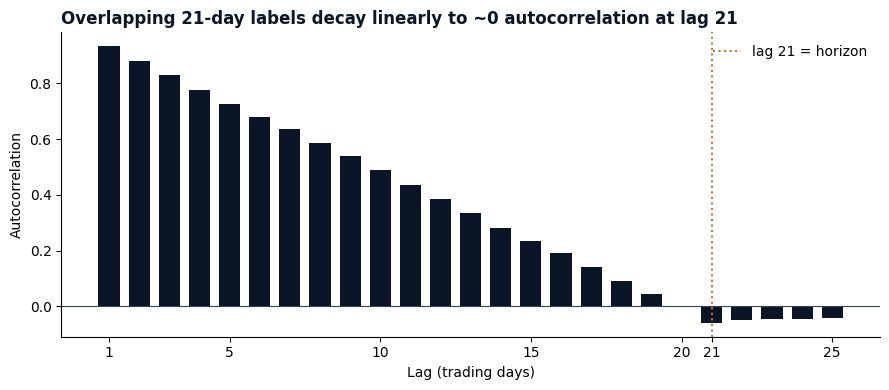

In [7]:
spy_labels = labels_df.filter(pl.col("symbol") == "SPY").sort("timestamp")
spy_ret21 = spy_labels["fwd_ret_21d"].drop_nulls().to_numpy()

max_lag = 25
lags = np.arange(1, max_lag + 1)
acf = np.array([np.corrcoef(spy_ret21[k:], spy_ret21[:-k])[0, 1] for k in lags])

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(lags, acf, color=COLORS["blue"], width=0.7)
ax.axhline(0, color=COLORS["neutral"], linewidth=0.8)
# The overlap length is horizon - 1 = 20 days: labels sharing no calendar days
# (lag >= 21) are essentially uncorrelated. This lag sets the HAC window (Sec 5)
# and the CV purge gap.
ax.axvline(21, color=COLORS["copper"], linestyle=":", linewidth=1.5, label="lag 21 = horizon")
ax.set_xlabel("Lag (trading days)")
ax.set_ylabel("Autocorrelation")
ax.set_title(
    "Overlapping 21-day labels decay linearly to ~0 autocorrelation at lag 21",
    loc="left",
    color=COLORS["blue"],
    fontweight="semibold",
)
ax.set_xticks([1, 5, 10, 15, 20, 21, 25])
ax.legend(loc="upper right", frameon=False)
sns.despine()
fig.tight_layout()
plt.show()

## 5. Baseline IC: Raw Momentum vs Labels

Before feature engineering, we establish baseline signal quality.
The IC of raw 126-day momentum against each label type sets the bar
that engineered features must clear.

In [8]:
# Baseline signal: raw 126d momentum. To keep this expectation-setting
# diagnostic strictly out-of-holdout, we purge on the LABEL endpoint, not just
# the signal date: a row dated just before holdout_start still has a forward
# label that reaches h days into the holdout window. Requiring the label's
# forward endpoint (timestamp shifted -h) to fall before holdout_start seals
# that boundary overlap (the same purge the Sec 4.1 autocorrelation motivates).
def baseline_frame(label_col: str, horizon: int) -> pl.DataFrame:
    """126d momentum vs `label_col`, using only rows whose label ends pre-holdout."""
    holdout = date.fromisoformat(holdout_start)
    return (
        labels_df.with_columns(
            (pl.col("close") / pl.col("close").shift(126).over("symbol") - 1).alias("raw_mom_126d"),
            pl.col("timestamp").shift(-horizon).over("symbol").alias("_label_end"),
        )
        .filter(pl.col("_label_end") < holdout)
        .drop_nulls(subset=["raw_mom_126d", label_col])
    )


# IC = rank correlation between signal and label
def compute_ic_by_date(df: pl.DataFrame, signal_col: str, label_col: str) -> pl.DataFrame:
    """Compute cross-sectional rank IC at each date."""
    # Rank both signal and label within each date
    ranked = df.with_columns(
        pl.col(signal_col).rank().over("timestamp").alias("_signal_rank"),
        pl.col(label_col).rank().over("timestamp").alias("_label_rank"),
    )

    # Pearson correlation of ranks = Spearman IC
    ic_by_date = (
        ranked.group_by("timestamp")
        .agg(
            pl.corr("_signal_rank", "_label_rank").alias("ic"),
            pl.len().alias("n"),
        )
        .filter(pl.col("n") >= 20)  # Need sufficient cross-section for reliable IC
        .sort("timestamp")
    )
    return ic_by_date


ic_21d = compute_ic_by_date(baseline_frame("fwd_ret_21d", 21), "raw_mom_126d", "fwd_ret_21d")
ic_5d = compute_ic_by_date(baseline_frame("fwd_ret_5d", 5), "raw_mom_126d", "fwd_ret_5d")


def fmt_ic(ic_df: pl.DataFrame, horizon: int) -> str:
    """Mean IC with Newey-West HAC-adjusted significance.

    The daily-sampled IC series inherits the label's overlap autocorrelation
    (Section 4.1), so the naive t-stat overstates significance. HAC (Bartlett
    kernel, lag = horizon - 1) corrects for it.
    """
    ic_clean = ic_df.drop_nulls(subset=["ic"])
    if ic_clean.height == 0:
        return "N/A (insufficient cross-section)"
    stats = compute_ic_hac_stats(ic_clean, ic_col="ic", label_horizon=horizon)
    return (
        f"mean={stats['mean_ic']:.4f}, HAC t={stats['t_stat']:.2f} "
        f"(naive t={stats['naive_t_stat']:.2f}, lag={stats['effective_lags']}), "
        f"p={stats['p_value']:.3f}"
    )


print(f"Baseline IC (raw 126d momentum, train+val only, < {holdout_start}):")
print(f"  vs fwd_ret_21d: {fmt_ic(ic_21d, 21)}")
print(f"  vs fwd_ret_5d:  {fmt_ic(ic_5d, 5)}")

Baseline IC (raw 126d momentum, train+val only, < 2024-01-01):
  vs fwd_ret_21d: mean=0.0257, HAC t=1.44 (naive t=5.07, lag=20), p=0.151
  vs fwd_ret_5d:  mean=0.0244, HAC t=2.42 (naive t=4.61, lag=9), p=0.016


**Interpretation**: The baseline IC sets expectations for downstream feature
engineering. Because daily labels at a 21-day horizon overlap by 20 days, the
naive t-stat is inflated; the HAC-adjusted t-stat (Newey-West, lag = horizon
- 1) is the honest significance test and is materially smaller. The IC level
for 126-day momentum against monthly returns is consistent with the
cross-asset momentum literature (Moskowitz, Ooi, and Pedersen 2012). The 5-day
label IC helps assess whether weekly rebalancing could improve signal capture
despite higher turnover costs.

## 6. Save Artifacts

Outputs:
- `labels/fwd_ret_21d.parquet` -- Primary regression label
- `labels/fwd_ret_5d.parquet` -- Variant regression label
- `cv_config.json` -- Walk-forward CV configuration

In [9]:
labels_out = labels_df
label_keys = ["timestamp", "symbol"]

LABELS_DIR.mkdir(parents=True, exist_ok=True)

# Regression labels
labels_out.select(label_keys + ["fwd_ret_21d"]).drop_nulls().write_parquet(
    LABELS_DIR / "fwd_ret_21d.parquet"
)
labels_out.select(label_keys + ["fwd_ret_5d"]).drop_nulls().write_parquet(
    LABELS_DIR / "fwd_ret_5d.parquet"
)
print("Saved labels/fwd_ret_21d.parquet, labels/fwd_ret_5d.parquet")

# CV config
cv_config = get_cv_config("etfs")
cv_config.to_json(CASE_DIR / "config" / "cv_config.json")
print(f"Saved cv_config.json (n_splits={cv_config.n_splits})")

Saved labels/fwd_ret_21d.parquet, labels/fwd_ret_5d.parquet
Saved cv_config.json (n_splits=8)


## Key Takeaways

1. **Two regression horizons** (21d primary, 5d variant) enable horizon
   sensitivity analysis: if IC is higher at 5d, weekly rebalancing may
   improve signal capture despite higher costs
2. **Baseline IC** of raw 126d momentum sets the bar for Ch8 features — but
   only under HAC-adjusted significance: the 20-day label overlap inflates the
   naive t-stat, and the 21d baseline is not significant after correction.
   Engineered features must clear this honest bar, not the illusory one
3. **CV config** saved from `setup.yaml` ensures downstream chapters use
   identical walk-forward splits

**Next**: `03_financial_features.py` builds engineered features and evaluates them
against these labels.